# Analysis of the embeddings produced by node2vec 

Goal of this analysis is to deeper understand the embeddings produced by Node2Vec and to decide on the 
architecture of downstream link prediction task.

Note: to be able to use all crisp methods, you need to install some additional packages:  {'bayanpy', 'wurlitzer', 'leidenalg', 'graph_tool', 'infomap'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'leidenalg', 'infomap', 'wurlitzer'}
Number of nodes: 34
Acquiring
Using 12 threads
F1 score: (0.776517273576097, 0.7655324875048057, 0.7709857554979017)
Average product of connected nodes: 2.819054812265576
Standard deviation of products of connected nodes: 1.0524141035048575
Average product of non-connected nodes: 1.6442877068470068
Standard deviation of products of non-connected nodes: 0.8191939364700102


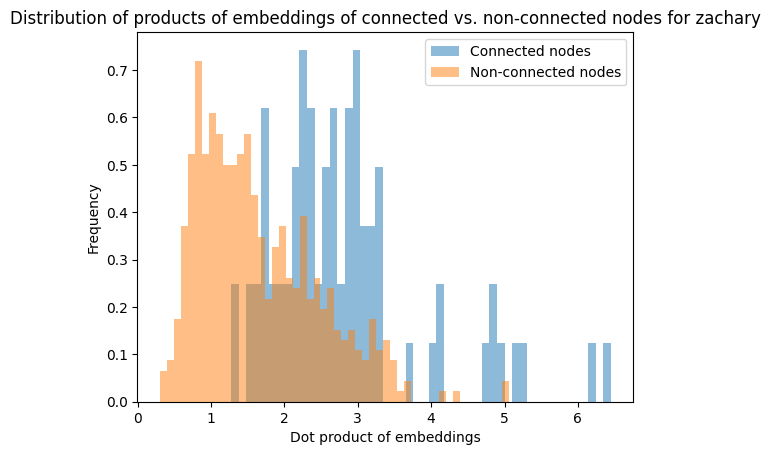

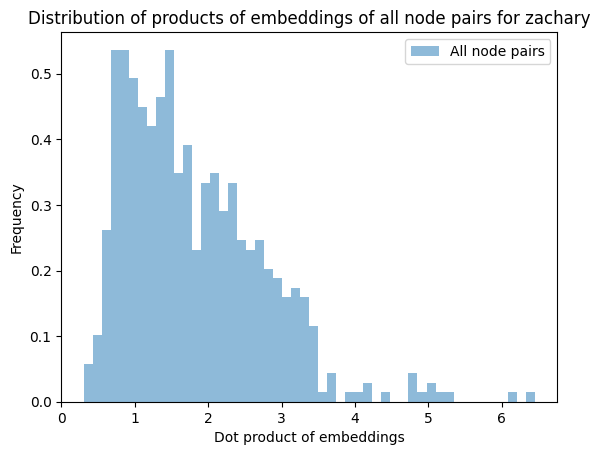

Standard deviation of products of all node pairs: 0.9470859064324669
std dev of connected - std dev of all: 0.1053281970723906
Number of nodes: 3264
Acquiring
Using 12 threads
F1 score: (0.5846954112091075, 0.24707997782446306, 0.3473690881945075)
Average product of connected nodes: 17.78998616600724
Standard deviation of products of connected nodes: 6.074932252555313
Average product of non-connected nodes: 8.140700083971664
Standard deviation of products of non-connected nodes: 2.910117727615563


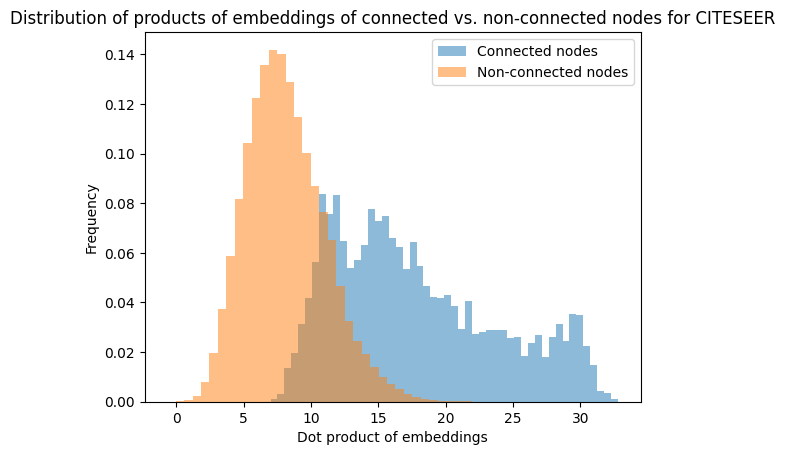

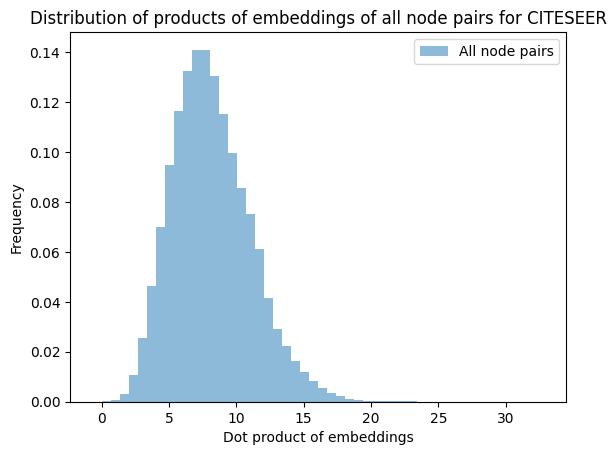

Standard deviation of products of all node pairs: 2.927840331677062
std dev of connected - std dev of all: 3.147091920878251


In [1]:
from vertex_voyage.persist import PersistedRun
from vertex_voyage.reconstruction import reconstruct, get_f1_score
import matplotlib.pyplot as plt
import os 
import numpy as np
import networkx as nx
run = PersistedRun("data/")

# ! scp -r 'stefy.xyz:~/vertexvoyage/runs/Cit-HepPh-partitions-lpa-1' data/Cit-HepPh
# ! ls data/zachary
# ! mv data/zachary/model* data/zachary/model.pkl
# ! mv data/CITESEER/model* data/CITESEER/model.pkl
# ! mv data/Cit-HepPh/model* data/Cit-HepPh/model.pkl

def investigate_dataset(name):
    graph = run[f"{name}/graph"]
    graph_model = run[f"{name}/model"]
    print("Number of nodes:", graph.number_of_nodes())
    embeddings = graph_model.embed_nodes(graph.nodes())
    reconstructed = reconstruct(graph.number_of_edges(), embeddings)
    f1 = get_f1_score(graph, reconstructed)
    print("F1 score:", f1)
    products = [] 
    for x,y in graph.edges():
        ex = embeddings[x]
        ey = embeddings[y]
        products.append(np.dot(ex, ey))
    products = np.array(products)
    print("Average product of connected nodes:", np.mean(products))
    print("Standard deviation of products of connected nodes:", np.std(products))
    # We want to see distribution of products of embeddings of connected nodes vs. non-connected nodes.
    non_connected_products = []
    for x,y in nx.non_edges(graph):
        ex = embeddings[x]
        ey = embeddings[y]
        non_connected_products.append(np.dot(ex, ey))
    non_connected_products = np.array(non_connected_products)
    print("Average product of non-connected nodes:", np.mean(non_connected_products))
    print("Standard deviation of products of non-connected nodes:", np.std(non_connected_products))

    # Plot the distribution of products of connected vs. non-connected nodes.
    plt.hist(products, bins=50, alpha=0.5, label="Connected nodes", density=True)
    plt.hist(non_connected_products, bins=50, alpha=0.5, label="Non-connected nodes", density=True)
    plt.legend()
    plt.title("Distribution of products of embeddings of connected vs. non-connected nodes for " + name)
    plt.xlabel("Dot product of embeddings")
    plt.ylabel("Frequency")
    plt.show()
    # plot the distribution of dot products regardless of connectivity
    all_products = np.concatenate([products, non_connected_products])
    plt.hist(all_products, bins=50, alpha=0.5, label="All node pairs", density=True)
    plt.legend()
    plt.title("Distribution of products of embeddings of all node pairs for " + name)
    plt.xlabel("Dot product of embeddings")
    plt.ylabel("Frequency")
    plt.show()
    print("Standard deviation of products of all node pairs:", np.std(all_products))
    print("std dev of connected - std dev of all:", np.std(products) - np.std(all_products))

investigate_dataset("zachary")
investigate_dataset("CITESEER")
# investigate_dataset("Cit-HepPh")

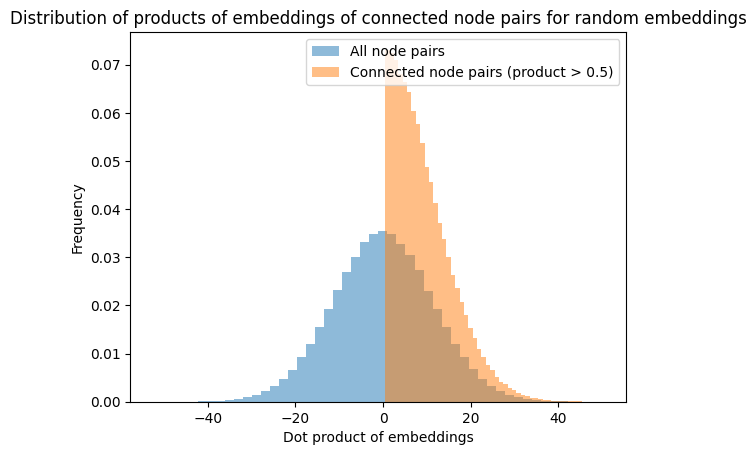

In [2]:
# Generate embeddings artificially where each vector is 128 dimensional and follows normal distribution with 0 mean and 1 standard deviation. 

embeddings = np.random.normal(0, 1, (1000, 128))

graph = nx.Graph()

def iter_dot_products(embeddings):
    for i in range(len(embeddings)):
        for j in range(i+1, len(embeddings)):
            ex = embeddings[i]
            ey = embeddings[j]
            yield i, j, ex, ey,np.dot(ex, ey)

# Compute dot products of all pairs of embeddings and plot the distribution.
products = []
for i, j, ex, ey, product in iter_dot_products(embeddings):
    products.append(product)
products = np.array(products)
plt.hist(products, bins=50, alpha=0.5, label="All node pairs", density=True)
plt.legend()
plt.title("Distribution of products of embeddings of all node pairs for random embeddings")
plt.xlabel("Dot product of embeddings")
plt.ylabel("Frequency")
connected_products = []
for i, j, ex, ey, product in iter_dot_products(embeddings):
    if product > 5e-1:
        graph.add_edge(i, j)
        connected_products.append(product)
connected_products = np.array(connected_products)
plt.hist(connected_products, bins=50, alpha=0.5, label="Connected node pairs (product > 0.5)", density=True)
plt.legend()
plt.title("Distribution of products of embeddings of connected node pairs for random embeddings")
plt.xlabel("Dot product of embeddings")
plt.ylabel("Frequency")
plt.show()




Starting training...
Epoch 1/100, Loss: 0.7395
Validation Loss: 0.7427
------------------------------
Epoch 2/100, Loss: 0.1135
Validation Loss: 0.1140
------------------------------
Epoch 3/100, Loss: 0.0899
Validation Loss: 0.0904
------------------------------
Epoch 4/100, Loss: 0.0789
Validation Loss: 0.0794
------------------------------
Epoch 5/100, Loss: 0.0721
Validation Loss: 0.0726
------------------------------
Epoch 6/100, Loss: 0.0674
Validation Loss: 0.0680
------------------------------
Epoch 7/100, Loss: 0.0639
Validation Loss: 0.0645
------------------------------
Epoch 8/100, Loss: 0.0611
Validation Loss: 0.0617
------------------------------
Epoch 9/100, Loss: 0.0588
Validation Loss: 0.0594
------------------------------
Epoch 10/100, Loss: 0.0569
Validation Loss: 0.0575
------------------------------
Epoch 11/100, Loss: 0.0552
Validation Loss: 0.0559
------------------------------
Epoch 12/100, Loss: 0.0538
Validation Loss: 0.0545
------------------------------
Epoc

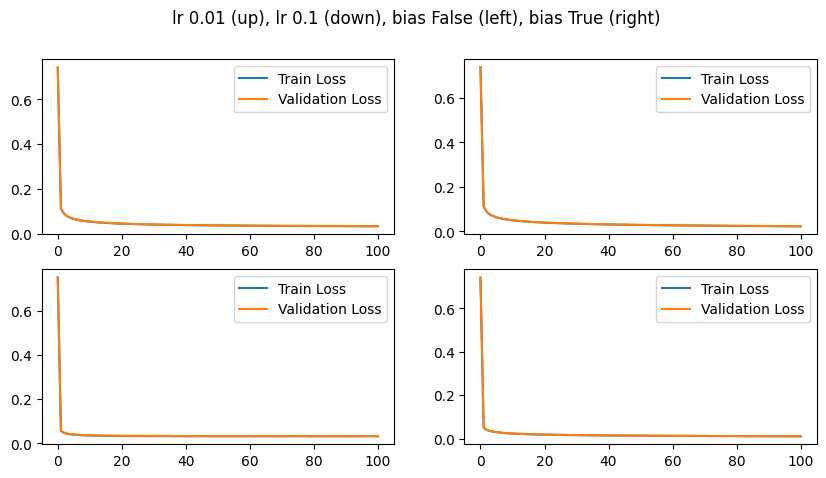

In [4]:
from vertex_voyage.tasks.link_prediction import HadamardLogitsNet, train_model
import random 
# Create positive samples from the graph edges
positive_samples = [(u, v) for u, v in graph.edges()]
# Create negative samples by sampling random pairs of nodes that are not connected
negative_samples = []
while len(negative_samples) < len(positive_samples):
    u = random.choice(list(graph.nodes()))
    v = random.choice(list(graph.nodes()))
    if not graph.has_edge(u, v) and u != v:
        negative_samples.append((u, v))
# Combine positive and negative samples
samples = positive_samples + negative_samples
labels = [1] * len(positive_samples) + [0] * len(negative_samples)
# Create feature vectors by taking the Hadamard product of the embeddings of the node pairs

# Create u_train, v_train, y_train, u_val, v_val, y_val
u_train, v_train, y_train = [], [], []
u_val, v_val, y_val = [], [], []
dataset = list(zip(samples, labels))
random.shuffle(dataset)
split_idx = int(0.8 * len(dataset))
train_data = dataset[:split_idx]
val_data = dataset[split_idx:]
for (u, v), label in train_data:
    u_train.append(embeddings[u])
    v_train.append(embeddings[v])
    y_train.append(label)
for (u, v), label in val_data:
    u_val.append(embeddings[u])
    v_val.append(embeddings[v])
    y_val.append(label)
u_train = np.array(u_train)
v_train = np.array(v_train)
y_train = np.array(y_train)
u_val = np.array(u_val)
v_val = np.array(v_val)
y_val = np.array(y_val)
fig, ax = plt.subplots(2, 2, figsize=(10, 5))
# Train a logistic regression model on the features and labels
for i, lr in enumerate([0.01, 0.1]):
    for j, bias in enumerate([False, True]):
        model = HadamardLogitsNet(vector_dim=embeddings.shape[1], use_bias=bias)
        model, train_losses, val_losses = train_model(model, u_train, v_train, y_train, u_val, v_val, y_val, epochs=100, learning_rate=lr)
        # plot training and validation losses for the current model
        ax[i, j].plot(train_losses, label="Train Loss")
        ax[i, j].plot(val_losses, label="Validation Loss")
        ax[i, j].legend()
plt.suptitle("lr 0.01 (up), lr 0.1 (down), bias False (left), bias True (right)")
plt.show()

Removed 42092 edges for testing.
Graph after edge removal has 378829 edges.
Starting training...
Epoch 1/60, Loss: 0.6851
Validation Loss: 0.6850
------------------------------
Epoch 2/60, Loss: 0.1028
Validation Loss: 0.1014
------------------------------
Epoch 3/60, Loss: 0.0969
Validation Loss: 0.0952
------------------------------
Epoch 4/60, Loss: 0.0952
Validation Loss: 0.0934
------------------------------
Epoch 5/60, Loss: 0.0945
Validation Loss: 0.0926
------------------------------
Epoch 6/60, Loss: 0.0941
Validation Loss: 0.0922
------------------------------
Epoch 7/60, Loss: 0.0941
Validation Loss: 0.0922
------------------------------
Epoch 8/60, Loss: 0.0939
Validation Loss: 0.0919
------------------------------
Epoch 9/60, Loss: 0.0939
Validation Loss: 0.0920
------------------------------
Epoch 10/60, Loss: 0.0939
Validation Loss: 0.0919
------------------------------
Epoch 11/60, Loss: 0.0938
Validation Loss: 0.0918
------------------------------
Epoch 12/60, Loss: 0.

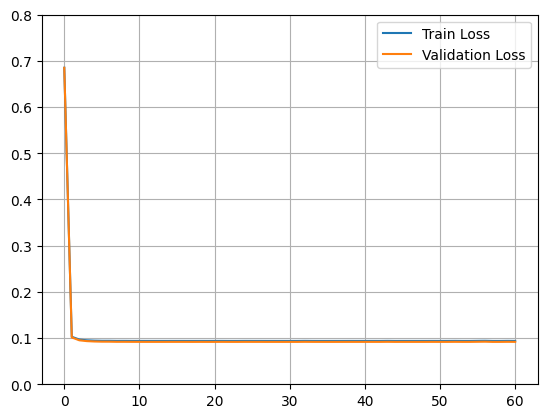

True Positives: 37272
False Positives: 1583
True Negatives: 40508
False Negatives: 4821
Precision: 0.9593
Recall: 0.8855
F1 Score: 0.9209
Accuracy: 0.9239


In [27]:

# %load_ext autoreload
# %autoreload 2
import importlib
import random 
import vertex_voyage.tasks.link_prediction 
importlib.reload(vertex_voyage.tasks.link_prediction)
from vertex_voyage.tasks.link_prediction import train_on_static_graph, predict_links
dataset = "Cit-HepPh"
citeseer = run[f"{dataset}/graph"]
# Remove 10% of the first edges for testing
removed_edges = list(citeseer.edges())[:int(0.1 * citeseer.number_of_edges())]   
print(f"Removed {len(removed_edges)} edges for testing.")
citeseer.remove_edges_from(removed_edges)
print(f"Graph after edge removal has {citeseer.number_of_edges()} edges.")
embedding_model = run[f"{dataset}/model"]
nodes = list(citeseer.nodes())
embeddings = embedding_model.embed_nodes(nodes)
model, train_losses, val_losses = train_on_static_graph(citeseer, embedding_model, epochs=60, use_bias=True,  cv_k=1, val_ratio=0.2, learning_rate=0.1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.ylim(0, 0.8)
plt.grid(True)
plt.show()

# Lets test the model on the removed edges and on some random non-edges.
positive_test_edges = removed_edges
negative_test_edges = []
while len(negative_test_edges) < len(positive_test_edges):
    u = random.choice(nodes)
    v = random.choice(nodes)
    if not citeseer.has_edge(u, v) and u != v:
        negative_test_edges.append((u, v))
test_edges = positive_test_edges + negative_test_edges
predictions = predict_links(test_edges, embedding_model, model)
TP, FP, TN, FN = 0, 0, 0, 0
for (u, v), (is_edge, prob) in zip(test_edges, predictions):
    if is_edge and (u, v) in positive_test_edges:
        TP += 1
    elif is_edge and (u, v) in negative_test_edges:
        FP += 1
    elif not is_edge and (u, v) in negative_test_edges:
        TN += 1
    elif not is_edge and (u, v) in positive_test_edges:
        FN += 1
print(f"True Positives: {TP}")
print(f"False Positives: {FP}")
print(f"True Negatives: {TN}")
print(f"False Negatives: {FN}")
print(f"Precision: {TP / (TP + FP) if TP + FP > 0 else 0:.4f}")
print(f"Recall: {TP / (TP + FN) if TP + FN > 0 else 0:.4f}")
print(f"F1 Score: {2 * TP / (2 * TP + FP + FN) if 2 * TP + FP + FN > 0 else 0:.4f}")
print(f"Accuracy: {(TP + TN) / (TP + FP + TN + FN) if TP + FP + TN + FN > 0 else 0:.4f}")

In [36]:
import importlib
import vertex_voyage.tasks.link_prediction
importlib.reload(vertex_voyage.tasks.link_prediction)
from vertex_voyage.tasks.link_prediction import ensemble_predict_links, generate_embedding_dict
embedding_dict = generate_embedding_dict(citeseer, embedding_model)
test_edges = positive_test_edges + negative_test_edges
predictions = ensemble_predict_links(test_edges, [embedding_dict], [model])
TP, FP, TN, FN = 0, 0, 0, 0
for (u, v), (is_edge, prob) in zip(test_edges, predictions):
    if is_edge and (u, v) in positive_test_edges:
        TP += 1
    elif is_edge and (u, v) in negative_test_edges:
        FP += 1
    elif not is_edge and (u, v) in negative_test_edges:
        TN += 1
    elif not is_edge and (u, v) in positive_test_edges:
        FN += 1
print(f"Ensemble - True Positives: {TP}")
print(f"Ensemble - False Positives: {FP}")
print(f"Ensemble - True Negatives: {TN}")
print(f"Ensemble - False Negatives: {FN}")
print(f"Ensemble - Precision: {TP / (TP + FP) if TP + FP > 0 else 0:.4f}")
print(f"Ensemble - Recall: {TP / (TP + FN) if TP + FN > 0 else 0:.4f}")
print(f"Ensemble - F1 Score: {2 * TP / (2 * TP + FP + FN) if 2 * TP + FP + FN > 0 else 0:.4f}")
print(f"Ensemble - Accuracy: {(TP + TN) / (TP + FP + TN + FN) if TP + FP + TN + FN > 0 else 0:.4f}")

Ensemble - True Positives: 37272
Ensemble - False Positives: 1583
Ensemble - True Negatives: 40508
Ensemble - False Negatives: 4821
Ensemble - Precision: 0.9593
Ensemble - Recall: 0.8855
Ensemble - F1 Score: 0.9209
Ensemble - Accuracy: 0.9239


embedding_dict.pkl
graph.pkl
lp_1f91c92dc85b075707390405c34b1da709cf89079e7a3af663ad696e431ab762.pkl
lp_3d429c6482d6bae39a91431bbb1f2d9cfddddb57d5487bb92134417f6bcccbb1.pkl
lp_799bac4ccf2b46b2ec7ba140d7a325c1a4033f44be20ef7a70d5544676902210.pkl
lp_a0a6f96c3a0d6bfe2924490a4a020b65ac1e14b84f5dbf7e5205f9274fa491c7.pkl
lp_a3a94f86fe7cda4767d291cbd3834b4f11ba55c36c86a9c72afac351bc8e770a.pkl
lp_a9049418589c7d90c1b3a205d28fb953e59732c0132dad7ac76d83d378cf0130.pkl
lp_ae43a248a57bd7de4547942e34052ee1a17d6001dc43a54d36dc9c8997da2bd9.pkl
lp_b2a1c4900805b7dcf0c0986e382f57162f38bfe5d3c094d47d3fa491333eea74.pkl
lp_c29c0acaadb72a02e4480bb2553f1e76603b5549be15f3272c6d5cfeb31b5422.pkl
lp_d7a648429dbd4ba867cd2fda2c1a7190b4c86eb070ec38fafe5d1b6b6aeb9426.pkl
lp_full.pkl
metadata.json
model_1f91c92dc85b075707390405c34b1da709cf89079e7a3af663ad696e431ab762.pkl
model_3d429c6482d6bae39a91431bbb1f2d9cfddddb57d5487bb92134417f6bcccbb1.pkl
model_799bac4ccf2b46b2ec7ba140d7a325c1a4033f44be20ef7a70d5544676902210.pkl


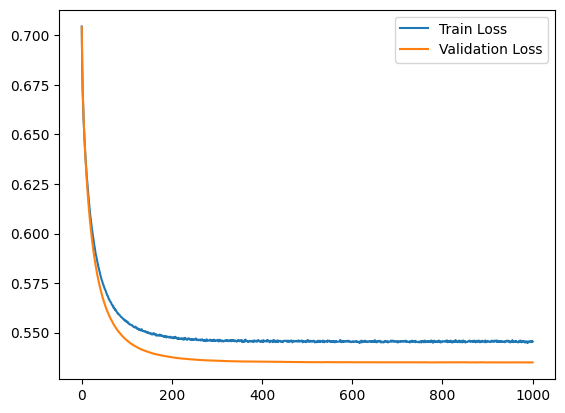

Dataset: Graph with 3264 nodes and 4536 edges
Partitions: {frozenset({2, 4, 8, 9, 11, 12, 19, 21, 23, 25, 27, 28, 30, 31, 33, 36, 43, 44, 45, 48, 50, 53, 62, 63, 67, 71, 72, 73, 74, 76, 77, 78, 79, 83, 89, 90, 96, 97, 99, 102, 103, 104, 105, 107, 110, 117, 120, 122, 124, 125, 126, 127, 128, 129, 131, 132, 133, 134, 141, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 157, 160, 161, 162, 164, 165, 166, 171, 173, 174, 175, 177, 182, 187, 188, 190, 191, 193, 195, 197, 198, 199, 201, 203, 204, 206, 209, 210, 213, 215, 216, 217, 218, 219, 220, 229, 230, 235, 236, 238, 240, 242, 244, 248, 251, 253, 256, 257, 259, 260, 261, 262, 264, 265, 268, 270, 271, 274, 277, 282, 285, 287, 289, 290, 291, 292, 294, 297, 298, 299, 303, 304, 305, 306, 307, 308, 309, 312, 314, 318, 320, 321, 322, 323, 325, 326, 327, 332, 333, 335, 336, 338, 340, 341, 342, 344, 345, 349, 351, 352, 353, 354, 356, 357, 360, 361, 362, 363, 365, 366, 367, 368, 371, 372, 375, 376, 377, 378, 389, 393, 397, 398, 399, 400, 401, 406

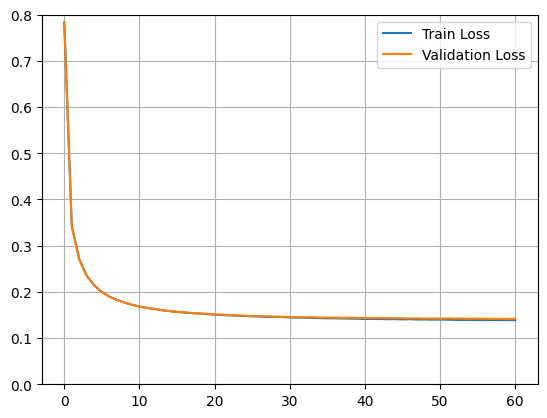

True Positives: 0
False Positives: 94
True Negatives: 2105
False Negatives: 2199
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
Accuracy: 0.4786


In [64]:

! cp ../cptest/* data/cptest/
! ls data/cptest

from vertex_voyage.cli import hash_set_persistently

class EM:
    def __init__(self, embedding_dict):
        self.embedding_dict = embedding_dict
    def embed_nodes(self, nodes):
        return [self.embed_node(n) for n in nodes]
    def embed_node(self, node):
        return self.embedding_dict[node]

run.data = {} 
model, train_losses, val_losses = run["cptest/lp_full"]
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.show()
em = EM(run["cptest/embedding_dict"])
dataset = run["cptest/graph"]
partitions = run["cptest/partitions"]
print("Dataset:", dataset)
print("Partitions:", partitions)
# lets remove links between partitions and see if the model can predict them
to_remove = []
partitions = list(partitions)
for i in range(len(partitions)):
    for j in range(i+1, len(partitions)):
        part_i = partitions[i]
        part_j = partitions[j]
        for u in part_i:
            for v in part_j:
                if dataset.has_edge(u, v):
                    to_remove.append((u, v))
print(f"Removing {len(to_remove)} edges between partitions.")
dataset.remove_edges_from(to_remove)
print(f"Graph after edge removal has {dataset.number_of_edges()} edges.")
model, train_losses, val_losses = train_on_static_graph(dataset, em, epochs=60, use_bias=True, cv_k=5, val_ratio=0.2, learning_rate=0.1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.ylim(0, 0.8)
plt.grid(True)
plt.show()
positive_test_edges = to_remove
negative_test_edges = []
while len(negative_test_edges) < len(positive_test_edges):
    u = random.choice(list(dataset.nodes()))
    v = random.choice(list(dataset.nodes()))
    if not dataset.has_edge(u, v) and u != v:
        negative_test_edges.append((u, v))
test_edges = positive_test_edges + negative_test_edges
predictions = predict_links(test_edges, em, model)
TP, FP, TN, FN = 0, 0, 0, 0
for (u, v), (is_edge, prob) in zip(test_edges, predictions):
    if is_edge and (u, v) in positive_test_edges:
        TP += 1
    elif is_edge and (u, v) in negative_test_edges:
        FP += 1
    elif not is_edge and (u, v) in negative_test_edges:
        TN += 1
    elif not is_edge and (u, v) in positive_test_edges:
        FN += 1
print(f"True Positives: {TP}")
print(f"False Positives: {FP}")
print(f"True Negatives: {TN}")
print(f"False Negatives: {FN}")
print(f"Precision: {TP / (TP + FP) if TP + FP > 0 else 0:.4f}")
print(f"Recall: {TP / (TP + FN) if TP + FN > 0 else 0:.4f}")
print(f"F1 Score: {2 * TP / (2 * TP + FP + FN) if 2 * TP + FP + FN > 0 else 0:.4f}")
print(f"Accuracy: {(TP + TN) / (TP + FP + TN + FN) if TP + FP + TN + FN > 0 else 0:.4f}")